In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [11]:
sales=pd.read_csv('/Users/shivanimittal/Desktop/BrightCart Sales Analytics_Project01/03_SQL/SQL FILES/sales_transactions_no_bom.csv')
print(sales.head())

    Order_ID  Order_Date Customer_ID Customer_Type     Lead_ID Region  \
0  ORD000004  2024-01-04  CUST100004           New  LEAD000007   West   
1  ORD000008  2024-01-06  CUST100008           New  LEAD000018   West   
2  ORD000009  2024-01-07  CUST100009           New  LEAD000019   West   
3  ORD000013  2024-01-07  CUST100013           New  LEAD000023  South   
4  ORD000001  2024-01-09  CUST100001           New  LEAD000001  North   

        City  Salesperson Customer_Segment          Channel  ...  \
0  Ahmedabad  Meera Joshi       Individual          Website  ...   
1       Pune  Meera Joshi              SME          Website  ...   
2  Ahmedabad  Meera Joshi       Individual          Website  ...   
3    Chennai    Sneha Rao       Individual          Website  ...   
4     Jaipur  Priya Verma              SME  Corporate Sales  ...   

  Gross_Sales_INR Net_Sales_INR Realized_Sales_INR   COGS_INR  \
0        3,499.00      3,324.05           3,324.05   1,800.00   
1       31,996.00     

In [13]:
leads=pd.read_csv('/Users/shivanimittal/Desktop/BrightCart Sales Analytics_Project01/03_SQL/SQL FILES/leads_pipeline_no_bom.csv')
print(leads.head())

      Lead_ID   Lead_Date Region       City  Salesperson Customer_Segment  \
0  LEAD000001  2024-01-01  North     Jaipur  Priya Verma              SME   
1  LEAD000002  2024-01-01  South  Bengaluru   Isha Reddy       Individual   
2  LEAD000003  2024-01-01  South  Bengaluru    Sneha Rao       Individual   
3  LEAD000004  2024-01-01   West     Mumbai  Rohan Mehta              SME   
4  LEAD000005  2024-01-01  South  Bengaluru    Sneha Rao       Individual   

          Lead_Source  Lead_Quality_Score  Lead_Cost_INR  Follow_ups  \
0  Corporate Outreach                  66         317.47           2   
1      Organic Search                  42          98.75           5   
2      Organic Search                  55          94.98           2   
3  Corporate Outreach                  69         297.51           4   
4      Organic Search                  73          76.64           1   

  Converted Conversion_Date  Days_to_Convert     Lost_Reason  
0       Yes      2024-01-09              

In [15]:
targets=pd.read_csv('/Users/shivanimittal/Desktop/BrightCart Sales Analytics_Project01/03_SQL/SQL FILES/monthly_targets_no_bom.csv')
print(targets.head())


     Month     Salesperson Region Sales_Target_INR  New_Customer_Target
0  2024-01    Aarav Sharma  North         3,44,694                   18
1  2024-01     Priya Verma  North         3,68,726                   18
2  2024-01  Karan Malhotra  North         3,86,276                   20
3  2024-01     Rohan Mehta   West         3,96,897                   20
4  2024-01     Meera Joshi   West         3,95,343                   18


In [17]:
products=pd.read_csv('/Users/shivanimittal/Desktop/BrightCart Sales Analytics_Project01/03_SQL/SQL FILES/product_master_no_bom.csv')
print(products.head())

  Product_Category            Product List_Price_INR Unit_Cost_INR  \
0      Electronics         Smartwatch          4,999         2,450   
1      Electronics   Wireless Earbuds          1,999           950   
2      Electronics  Bluetooth Speaker          2,799         1,380   
3      Electronics         Power Bank          1,499           720   
4      Electronics     Smart Home Hub          6,499         3,300   

  Launch_Date Base_Return_Rate  
0  2024-01-01             7.5%  
1  2024-01-01             9.0%  
2  2024-01-01             7.0%  
3  2024-01-01             5.5%  
4  2025-03-01             6.5%  


converted_dates

In [18]:
sales['Order_Date']=pd.to_datetime(sales['Order_Date'])
leads['Lead_Date']=pd.to_datetime(leads['Lead_Date'])
leads['Conversion_Date']=pd.to_datetime(
    leads['Conversion_Date'],
errors='coerce'

)
targets['Month']=pd.to_datetime(targets['Month'])
products['Launch_Date']=pd.to_datetime(
    products['Launch_Date']
)


In [19]:
leads.shape


(6500, 14)

In [20]:
sales.shape

(4476, 26)

In [21]:
products.shape

(20, 6)

In [22]:
targets.shape

(360, 5)

In [23]:
leads.isnull().sum()

Lead_ID                  0
Lead_Date                0
Region                   0
City                     0
Salesperson              0
Customer_Segment         0
Lead_Source              0
Lead_Quality_Score       0
Lead_Cost_INR            0
Follow_ups               0
Converted                0
Conversion_Date       3056
Days_to_Convert       3056
Lost_Reason           3444
dtype: int64

In [24]:
leads.info()

<class 'pandas.DataFrame'>
RangeIndex: 6500 entries, 0 to 6499
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Lead_ID             6500 non-null   str           
 1   Lead_Date           6500 non-null   datetime64[us]
 2   Region              6500 non-null   str           
 3   City                6500 non-null   str           
 4   Salesperson         6500 non-null   str           
 5   Customer_Segment    6500 non-null   str           
 6   Lead_Source         6500 non-null   str           
 7   Lead_Quality_Score  6500 non-null   int64         
 8   Lead_Cost_INR       6500 non-null   float64       
 9   Follow_ups          6500 non-null   int64         
 10  Converted           6500 non-null   str           
 11  Conversion_Date     3444 non-null   datetime64[us]
 12  Days_to_Convert     3444 non-null   float64       
 13  Lost_Reason         3056 non-null   str           
dtypes: 

Create useful helper columns

In [25]:
sales['Returned']=(
    sales['Return_Flag']=='Yes'
).astype(int)

In [26]:
sales['Returned'].dtypes

dtype('int64')

Create discount groups:

In [27]:
sales.columns


Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Customer_Type', 'Lead_ID',
       'Region', 'City', 'Salesperson', 'Customer_Segment', 'Channel',
       'Campaign', 'Product_Category', 'Product', 'Units', 'Unit_Price_INR',
       'Discount_Pct', 'Gross_Sales_INR', 'Net_Sales_INR',
       'Realized_Sales_INR', 'COGS_INR', 'Shipping_Cost_INR', 'Profit_INR',
       'Return_Flag', 'Delivery_Days', 'Satisfaction_Score', 'Payment_Method',
       'Returned'],
      dtype='str')

In [28]:
sales['Discount_Band']=pd.cut(
    sales['Discount_Pct'],
    bins=[-1,5,10,15,20,100],
    labels=[
        '0-5%',
        '6-10%',
        '11-15%',
        '16-20%',
        '21%+'
    ]
)


Create delivery groups:

In [29]:
sales['Delivery_Groups']=pd.cut(
    sales['Delivery_Days'],
    bins=[-1,3,7,100],
    labels=[
        "Fast: 0-3 days",
        "Normal: 4-7 days",
        "Slow: 8+ days"
    ]
)


Discount VS Profit

In [30]:
discount_analysis=(
    sales
    .groupby("Discount_Band",
             observed=False
    )
    .agg(
        Orders=("Order_ID","nunique"),
        Sales=("Realized_Sales_INR","sum"),
        Profit=("Profit_INR","sum"),
        Returns=("Returned","mean")
    )
    .reset_index()
)
discount_analysis

,Discount_Band,Orders,Sales,Profit,Returns
0,0-5%,1254,"3,324.054,999.006,648.102,184.054,749.051,424....","1,378.052,277.003,048.10900.052,105.05539.0515...",0.050239
1,6-10%,1220,"1,079.104,499.106,299.100.008,099.1010,799.108...","457.101,528.102,249.10-510.002,689.103,599.102...",0.031967
2,11-15%,1089,"27,196.601,274.151,954.155,949.150.008,153.208...","8,444.60353.15904.151,579.15-453.003,978.202,3...",0.062443
3,16-20%,655,"959.200.000.00959.205,599.203,198.403,199.200....","260.20-401.00-682.00266.201,438.201,063.40882....",0.093130
4,21%+,258,"74,992.503,749.258,621.2522,495.5013,498.502,0...","14,951.50706.253,130.255,631.502,910.50617.252...",0.050388


Add profit margin:

In [35]:
discount_analysis["Profit_Margin_Pct"] = (
    discount_analysis["Profit"] /
    discount_analysis["Sales"]
) * 100

In [32]:
discount_analysis.dtypes

Discount_Band    category
Orders              int64
Sales                 str
Profit                str
Returns           float64
dtype: object

In [33]:
sales["Realized_Sales_INR"] = pd.to_numeric(
    sales["Realized_Sales_INR"].astype(str).str.replace(",", ""),
    errors="coerce"
)

sales["Profit_INR"] = pd.to_numeric(
    sales["Profit_INR"].astype(str).str.replace(",", ""),
    errors="coerce"
)

In [34]:
discount_analysis = sales.groupby("Discount_Band", observed=True).agg(
    Orders=("Order_ID", "count"),
    Sales=("Realized_Sales_INR", "sum"),
    Profit=("Profit_INR", "sum"),
    Returns=("Returned", "sum")
).reset_index()

In [27]:
discount_analysis["Sales"] = pd.to_numeric(
    discount_analysis["Sales"],
    errors="coerce"
)

discount_analysis["Profit"] = pd.to_numeric(
    discount_analysis["Profit"],
    errors="coerce"
)

In [36]:
discount_analysis["Returned_Rate_Pct"] = (
    discount_analysis["Returns"] /
    discount_analysis["Orders"] * 100
)
discount_analysis


,Discount_Band,Orders,Sales,Profit,Returns,Profit_Margin_Pct,Returned_Rate_Pct
0,0-5%,1254,14098307.32,5797760.32,63,41.123804,5.023923
1,6-10%,1220,14440390.92,5380826.92,39,37.262336,3.196721
2,11-15%,1089,15941663.77,5244610.77,68,32.898767,6.244261
3,16-20%,655,8882888.81,2592781.81,61,29.188498,9.312977
4,21%+,258,4333188.03,1048003.03,13,24.185496,5.038760


Charts:


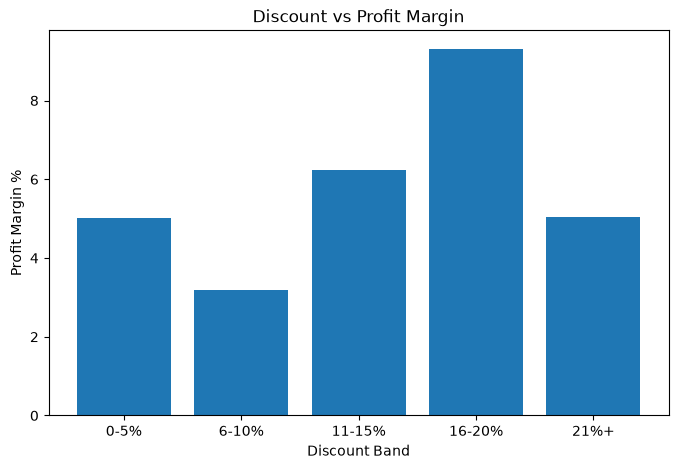

In [37]:
plt.figure(figsize=(8,5))

plt.bar(
    discount_analysis["Discount_Band"].astype(str),
    discount_analysis["Returned_Rate_Pct"]
)

plt.xlabel("Discount Band")
plt.ylabel("Profit Margin %")
plt.title("Discount vs Profit Margin")

plt.show()

In [38]:
discount_analysis

,Discount_Band,Orders,Sales,Profit,Returns,Profit_Margin_Pct,Returned_Rate_Pct
0,0-5%,1254,14098307.32,5797760.32,63,41.123804,5.023923
1,6-10%,1220,14440390.92,5380826.92,39,37.262336,3.196721
2,11-15%,1089,15941663.77,5244610.77,68,32.898767,6.244261
3,16-20%,655,8882888.81,2592781.81,61,29.188498,9.312977
4,21%+,258,4333188.03,1048003.03,13,24.185496,5.038760


In [39]:
print(discount_analysis.columns)

Index(['Discount_Band', 'Orders', 'Sales', 'Profit', 'Returns',
       'Profit_Margin_Pct', 'Returned_Rate_Pct'],
      dtype='str')


Delivery vs Satisfaction and returns

In [40]:
delivery_analysis=(
    sales
    .groupby("Delivery_Groups",
             observed=False)
.agg(
        Orders=("Order_ID","nunique"),
        Satisfaction=("Satisfaction_Score","mean"),
        Return_rate=("Returned","mean")
    )
    .reset_index()
)
delivery_analysis

,Delivery_Groups,Orders,Satisfaction,Return_rate
0,Fast: 0-3 days,1572,4.269084,0.043893
1,Normal: 4-7 days,2314,3.892394,0.053155
2,Slow: 8+ days,590,2.984746,0.088136


In [41]:
print(sales.columns)

Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Customer_Type', 'Lead_ID',
       'Region', 'City', 'Salesperson', 'Customer_Segment', 'Channel',
       'Campaign', 'Product_Category', 'Product', 'Units', 'Unit_Price_INR',
       'Discount_Pct', 'Gross_Sales_INR', 'Net_Sales_INR',
       'Realized_Sales_INR', 'COGS_INR', 'Shipping_Cost_INR', 'Profit_INR',
       'Return_Flag', 'Delivery_Days', 'Satisfaction_Score', 'Payment_Method',
       'Returned', 'Discount_Band', 'Delivery_Groups'],
      dtype='str')


New Vs Returning Customers


In [42]:
customer_type_analysis=(
    sales
    .groupby("Customer_Type")
    .agg(
        Customers=("Customer_ID","nunique"),
        Orders=("Order_ID","nunique"),
        Sales=("Realized_Sales_INR","sum"),
        Profit=("Profit_INR","sum"),
        Satisfaction=("Satisfaction_Score","mean"),
        Return_rate=("Returned","mean")
    )
)
customer_type_analysis["AOV"] = (
    customer_type_analysis["Sales"] /
    customer_type_analysis["Orders"]
)

customer_type_analysis


,Customers,Orders,Sales,Profit,Satisfaction,Return_rate,AOV
Customer_Type,,,,,,,
New,3444,3444,43363640.30,14782942.30,3.923345,0.057201,12591.068612
Returning,870,1032,14332798.55,5281040.55,3.843992,0.045543,13888.370688


Repeat Customers


In [43]:
customer_summary = (
    sales
    .groupby("Customer_ID")
    .agg(
        Sales=("Realized_Sales_INR", "sum"),
        Orders=("Order_ID", "nunique"),
        Profit=("Profit_INR", "sum")
    )
    .reset_index()
)


Repeat Customers By City

In [44]:
customer_location = (
    sales
    .sort_values("Order_Date")
    .drop_duplicates("Customer_ID")
    [
        [
            "Customer_ID",
            "City",
            "Region",
            "Customer_Segment"
        ]
    ]
)

In [45]:
customer_summary = customer_summary.merge(
    customer_location,
    on="Customer_ID",
    how="left"
)


In [46]:
customer_summary["Repeat_Customer"] = (
    customer_summary["Orders"] > 1
)


In [47]:
repeat_rate = customer_summary["Repeat_Customer"].mean() * 100
print(f"Repeat customer rate: {repeat_rate:.2f}%")


Repeat customer rate: 25.26%


In [48]:
sales.columns

Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Customer_Type', 'Lead_ID',
       'Region', 'City', 'Salesperson', 'Customer_Segment', 'Channel',
       'Campaign', 'Product_Category', 'Product', 'Units', 'Unit_Price_INR',
       'Discount_Pct', 'Gross_Sales_INR', 'Net_Sales_INR',
       'Realized_Sales_INR', 'COGS_INR', 'Shipping_Cost_INR', 'Profit_INR',
       'Return_Flag', 'Delivery_Days', 'Satisfaction_Score', 'Payment_Method',
       'Returned', 'Discount_Band', 'Delivery_Groups'],
      dtype='str')

In [49]:
city_repeat = (
    customer_summary
    .groupby("City")
    .agg(
        Customers=("Customer_ID", "nunique"),
        Repeat_Rate=("Repeat_Customer", "mean"),
        Customer_Sales=("Sales", "sum")
    )
    .reset_index()
)

city_repeat["Repeat_Rate_Pct"] = city_repeat["Repeat_Rate"] * 100
city_repeat = city_repeat.drop(columns="Repeat_Rate")
city_repeat


,City,Customers,Customer_Sales,Repeat_Rate_Pct
0,Ahmedabad,258,3555083.80,24.418605
1,Bengaluru,344,6318817.55,22.965116
2,Bhubaneswar,103,2004047.65,16.504854
3,Chennai,336,4292289.72,24.702381
4,Delhi,440,8446647.85,24.090909
5,Guwahati,69,1148198.13,21.739130
6,Hyderabad,437,7149006.26,24.256293
7,Jaipur,289,4488816.31,22.145329
8,Kolkata,180,3357918.92,25.000000
9,Lucknow,209,3581649.18,29.186603


Monthly_Trend


In [50]:
sales["Month"] = (
    sales["Order_Date"]
    .dt
    .to_period("M")
    .dt
    .to_timestamp()
)

In [51]:
monthly=(
    sales.groupby("Month").agg(
        Sales=("Realized_Sales_INR","sum"),
        Profit=("Profit_INR","sum"),
        Orders=("Order_ID","nunique")
    )
    .reset_index()
)
monthly

,Month,Sales,Profit,Orders
0,2024-01-01,314069.35,100971.35,43
1,2024-02-01,954237.60,337581.60,83
2,2024-03-01,1013061.64,370626.64,100
3,2024-04-01,1008170.80,353770.80,105
4,2024-05-01,1313129.80,454367.80,102
5,2024-06-01,1069161.27,379271.27,107
6,2024-07-01,1373035.79,481812.79,127
7,2024-08-01,1820527.98,614301.98,134
8,2024-09-01,2229454.31,776966.31,130
9,2024-10-01,1925009.91,616528.91,163


In [52]:
monthly["MoM_Growth_Pct"] = (
    monthly["Sales"]
    .pct_change()
    * 100
)

In [53]:
monthly["MoM_Growth_Pct"] = (
    monthly["Sales"]
    .pct_change()
    * 100
)

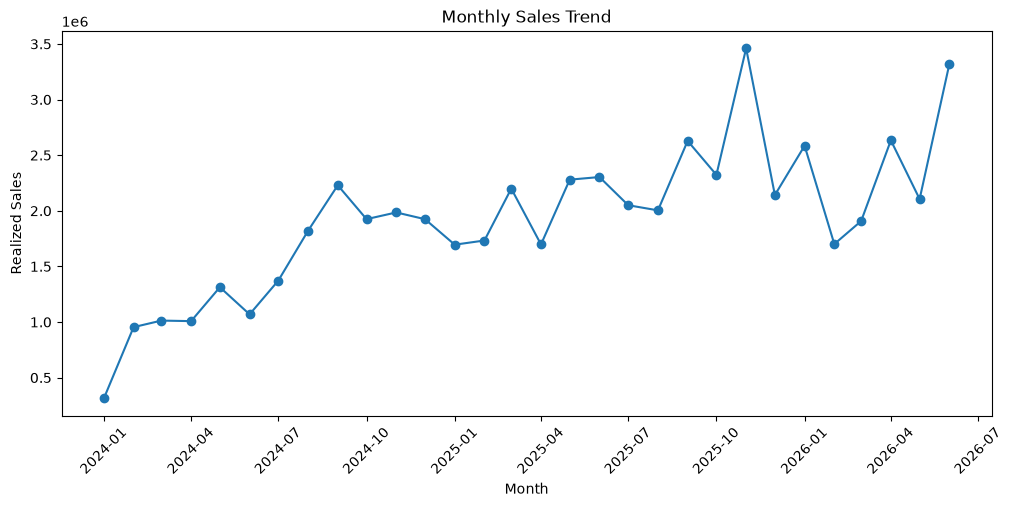

In [54]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly["Month"],
    monthly["Sales"],
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Realized Sales")
plt.title("Monthly Sales Trend")

plt.xticks(rotation=45)

plt.show()

Lead Source Analysis

In [55]:
leads["Converted_Flag"]=(
    leads["Converted"]=="Yes"
).astype(int)

In [56]:
lead_source_analysis=(
    leads.groupby("Lead_Source").agg(
        Leads=("Lead_ID","nunique"),
        Converted=("Converted_Flag","sum"),
        Total_lead_cost=("Days_to_Convert","mean")
    )
    .reset_index()
)

Conversion

In [57]:
lead_source_analysis["Converted_Rate_Pct"]=(
    lead_source_analysis["Converted"]/
    lead_source_analysis["Leads"]
)*100

cost:

In [58]:
lead_source_analysis["Cost_Per_Converted_Lead"]=(
   lead_source_analysis["Total_lead_cost"]/
    lead_source_analysis["Converted"]
)

In [59]:
lead_source_analysis.sort_values(
    "Converted_Rate_Pct",
    ascending=False
)

,Lead_Source,Leads,Converted,Total_lead_cost,Converted_Rate_Pct,Cost_Per_Converted_Lead
5,Referral,921,695,8.676259,75.461455,0.012484
6,Walk-in,741,500,8.544000,67.476383,0.017088
2,Marketplace,897,539,7.502783,60.089186,0.013920
3,Organic Search,1366,703,14.385491,51.464129,0.020463
1,Google Ads,1113,513,14.315789,46.091644,0.027906
0,Corporate Outreach,493,191,20.146597,38.742394,0.105480
4,Paid Social,969,303,13.613861,31.269350,0.044930
